Rows: 792 | Unique elements: 22 | TOPN: 22 | First 10 top elements: ['N', 'C', 'H', 'O', 'Hf', 'Cr', 'Zr', 'Nb', 'Mo', 'Sc']


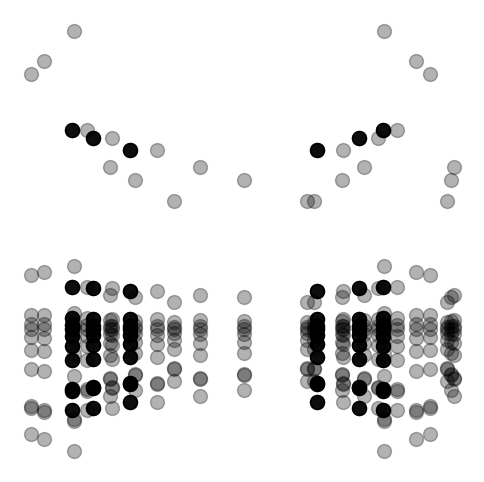

Saved: visual/fig5ai.jpg


In [1]:
# =========================
# MXene composition PCA plot (single color)
# - reads mxene_800.csv (column: "mxene" with formulas like Cr2CBr2)
# - parses formulas -> element fractions
# - builds top-N element composition vectors
# - PCA to 2D
# - scatter in one color (gray/black) with transparency
# =========================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from pathlib import Path

# -------------------------
# Paths
# -------------------------
DATA_PATH = "./data/mxene_800.csv"   # change if needed
OUT_DIR   = Path("./visual")
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_FIG   = OUT_DIR / "fig5ai.jpg"

# -------------------------
# Load
# -------------------------
df = pd.read_csv(DATA_PATH)

if "mxene" not in df.columns:
    raise ValueError(f"Expected a column named 'mxene'. Found columns: {list(df.columns)}")

# -------------------------
# Parse formula like "Cr2CBr2" -> {"Cr":2, "C":1, "Br":2} -> fractions
# -------------------------
pat = re.compile(r"([A-Z][a-z]?)(\d*\.?\d*)")

def formula_to_frac_dict(formula: str) -> dict:
    d = {}
    for el, num in pat.findall(str(formula)):
        n = float(num) if num else 1.0
        d[el] = d.get(el, 0.0) + n
    tot = sum(d.values())
    return {el: v / tot for el, v in d.items()} if tot > 0 else {}

df["comp_dict"] = df["mxene"].apply(formula_to_frac_dict)

# -------------------------
# Element frequency + top-N elements
# -------------------------
element_counts = {}
for comp in df["comp_dict"]:
    for el in comp:
        element_counts[el] = element_counts.get(el, 0) + 1

if len(element_counts) == 0:
    raise ValueError("No elements parsed. Check that df['mxene'] contains valid formulas.")

element_freq = (
    pd.DataFrame({"element": list(element_counts.keys()), "count": list(element_counts.values())})
      .sort_values("count", ascending=False)
      .reset_index(drop=True)
)

TOPN = min(100, len(element_freq))  # adjust if you want
top_elements = element_freq["element"].head(TOPN).tolist()

def comp_to_row(comp_dict, elems):
    return [comp_dict.get(el, 0.0) for el in elems]

X_comp = np.array([comp_to_row(cd, top_elements) for cd in df["comp_dict"]], dtype=float)

print(
    f"Rows: {len(df)} | Unique elements: {len(element_counts)} | "
    f"TOPN: {TOPN} | First 10 top elements: {top_elements[:10]}"
)

# -------------------------
# Remove empty rows (just in case)
# -------------------------
nonzero_mask = (X_comp.sum(axis=1) > 0)
X_nz = X_comp[nonzero_mask]

if X_nz.shape[0] < 2:
    raise ValueError(f"Not enough non-empty samples for PCA. X_nz shape: {X_nz.shape}")

# -------------------------
# PCA -> 2D
# -------------------------
RANDOM_STATE = 0
pca = PCA(n_components=2, random_state=RANDOM_STATE)
Z = pca.fit_transform(X_nz)

# -------------------------
# Plot (single color)
# -------------------------
MARKER_SIZE = 100
ALPHA = 0.3

plt.figure(figsize=(6, 6))
plt.scatter(
    Z[:, 0], Z[:, 1],
    color="black",     # change to "black" if you want
    s=MARKER_SIZE,
    alpha=ALPHA
)

# remove axes/ticks/frame
plt.xticks([])
plt.yticks([])
plt.xlabel("")
plt.ylabel("")
plt.box(False)

plt.savefig(OUT_FIG, format="jpg", dpi=500, bbox_inches="tight")
plt.show()

print(f"Saved: {OUT_FIG}")


Rows: 48 | Unique elements: 15 | TOPN: 15 | First 10 top elements: ['H', 'N', 'C', 'O', 'Sc', 'Y', 'Ti', 'Nb', 'Mo', 'Cr']


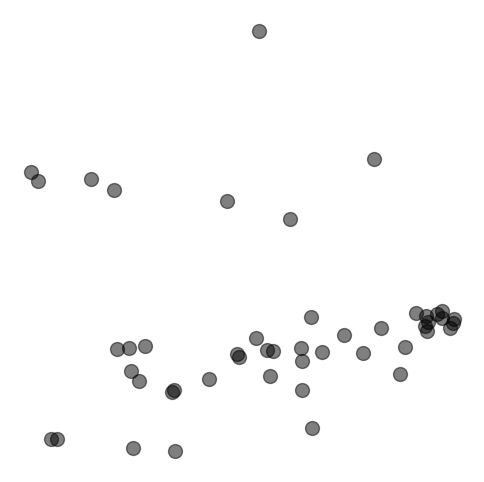

Saved: visual/fig5aii.jpg


In [4]:
# -------------------------
# Paths
# -------------------------
DATA_PATH = "./data/mxene_filtered.csv"   # change if needed
OUT_DIR   = Path("./visual")
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_FIG   = OUT_DIR / "fig5aii.jpg"

# -------------------------
# Load
# -------------------------
df = pd.read_csv(DATA_PATH)

if "mxene" not in df.columns:
    raise ValueError(f"Expected a column named 'mxene'. Found columns: {list(df.columns)}")

# -------------------------
# Parse formula like "Cr2CBr2" -> {"Cr":2, "C":1, "Br":2} -> fractions
# -------------------------
pat = re.compile(r"([A-Z][a-z]?)(\d*\.?\d*)")

def formula_to_frac_dict(formula: str) -> dict:
    d = {}
    for el, num in pat.findall(str(formula)):
        n = float(num) if num else 1.0
        d[el] = d.get(el, 0.0) + n
    tot = sum(d.values())
    return {el: v / tot for el, v in d.items()} if tot > 0 else {}

df["comp_dict"] = df["mxene"].apply(formula_to_frac_dict)

# -------------------------
# Element frequency + top-N elements
# -------------------------
element_counts = {}
for comp in df["comp_dict"]:
    for el in comp:
        element_counts[el] = element_counts.get(el, 0) + 1

if len(element_counts) == 0:
    raise ValueError("No elements parsed. Check that df['mxene'] contains valid formulas.")

element_freq = (
    pd.DataFrame({"element": list(element_counts.keys()), "count": list(element_counts.values())})
      .sort_values("count", ascending=False)
      .reset_index(drop=True)
)

TOPN = min(100, len(element_freq))  # adjust if you want
top_elements = element_freq["element"].head(TOPN).tolist()

def comp_to_row(comp_dict, elems):
    return [comp_dict.get(el, 0.0) for el in elems]

X_comp = np.array([comp_to_row(cd, top_elements) for cd in df["comp_dict"]], dtype=float)

print(
    f"Rows: {len(df)} | Unique elements: {len(element_counts)} | "
    f"TOPN: {TOPN} | First 10 top elements: {top_elements[:10]}"
)

# -------------------------
# Remove empty rows (just in case)
# -------------------------
nonzero_mask = (X_comp.sum(axis=1) > 0)
X_nz = X_comp[nonzero_mask]

if X_nz.shape[0] < 2:
    raise ValueError(f"Not enough non-empty samples for PCA. X_nz shape: {X_nz.shape}")

# -------------------------
# PCA -> 2D
# -------------------------
RANDOM_STATE = 0
pca = PCA(n_components=2, random_state=RANDOM_STATE)
Z = pca.fit_transform(X_nz)

# -------------------------
# Plot (single color)
# -------------------------
MARKER_SIZE = 100
ALPHA = 0.5

plt.figure(figsize=(6, 6))
plt.scatter(
    Z[:, 0], Z[:, 1],
    color="black",     # change to "black" if you want
    s=MARKER_SIZE,
    alpha=ALPHA
)

# remove axes/ticks/frame
plt.xticks([])
plt.yticks([])
plt.xlabel("")
plt.ylabel("")
plt.box(False)

plt.savefig(OUT_FIG, format="jpg", dpi=500, bbox_inches="tight")
plt.show()

print(f"Saved: {OUT_FIG}")
